In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import nltk
from nltk.tokenize import word_tokenize
nltk.download("punkt")

[nltk_data] Downloading package punkt to C:\Users\Ananjay
[nltk_data]     Pampalli\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [17]:
# =========================
# LOAD LIAR DATASET
# =========================

OUTPUT_DIR = Path("../outputs")

liar_train = pd.read_csv(OUTPUT_DIR / "train_processed.csv")
liar_test  = pd.read_csv(OUTPUT_DIR / "test_processed.csv")

liar_df = pd.concat([liar_train, liar_test], ignore_index=True)

# =========================
# LOAD ISOT DATASET
# =========================

fake_df = pd.read_csv("../data/ISOT/Fake.csv")
true_df = pd.read_csv("../data/ISOT/True.csv")

fake_df["label"] = 0
true_df["label"] = 1

# Keep only required columns
fake_df = fake_df[["text", "label"]]
true_df = true_df[["text", "label"]]

# =========================
# COMBINE DATASETS
# =========================

combined_df = pd.concat(
    [liar_df, fake_df, true_df],
    ignore_index=True
)

combined_df = combined_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(combined_df.shape)

combined_df.head()

(57689, 2)


,text,label
0,WASHINGTON (Reuters) - Public pension funds i...,1
1,"TURNBERRY, Scotland (Reuters) - Donald Trump f...",1
2,the best evidence is that you lose if you use ...,1
3,Only 38 states to go. Obama is going to do mor...,0
4,we have more scientists and engineers per squa...,1


In [18]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    combined_df,
    test_size=0.2,
    random_state=42,
    stratify=combined_df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df.shape)
print(test_df.shape)

(46151, 2)
(11538, 2)


In [19]:
def tokenize(text):
    return word_tokenize(text.lower())

train_tokens = [tokenize(text) for text in train_df["text"]]
test_tokens  = [tokenize(text) for text in test_df["text"]]

word_counts = Counter()
for tokens in train_tokens:
    word_counts.update(tokens)

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, count in word_counts.items():
    if count >= 2:
        vocab[word] = len(vocab)

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 106884


In [20]:
MAX_LEN = 300

def encode(tokens, vocab, max_len=MAX_LEN):
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens[:max_len]]
    return torch.tensor(ids, dtype=torch.long)

train_encoded = [encode(tokens, vocab) for tokens in train_tokens]
test_encoded  = [encode(tokens, vocab) for tokens in test_tokens]

In [21]:
class FakeNewsDataset(Dataset):
    def __init__(self, encoded_texts, labels):
        self.texts = encoded_texts
        self.labels = labels.values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], torch.tensor(self.labels[idx], dtype=torch.float)

def collate_fn(batch):
    texts, labels = zip(*batch)
    texts = pad_sequence(texts, batch_first=True, padding_value=0)
    texts = texts[:, :MAX_LEN]
    labels = torch.stack(labels)
    return texts, labels

train_dataset = FakeNewsDataset(train_encoded, train_df["label"])
test_dataset  = FakeNewsDataset(test_encoded, test_df["label"])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [22]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)

        pooled = torch.mean(out, dim=1)
        pooled = self.dropout(pooled)

        return torch.sigmoid(self.fc(pooled)).squeeze(1)

In [23]:
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.scale = hidden_dim ** 0.5

    def forward(self, x):
        scores = torch.bmm(x, x.transpose(1, 2)) / self.scale
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights, x)
        context = torch.mean(context, dim=1)
        return context, weights

In [24]:
class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        self.attention = SelfAttention(hidden_dim * 2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)

        context, attn_weights = self.attention(out)
        context = self.dropout(context)

        output = torch.sigmoid(self.fc(context)).squeeze(1)
        return output, attn_weights

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCELoss()

def train_model(model, train_loader, test_loader, epochs=5, attention=False):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)

            optimizer.zero_grad()

            if attention:
                outputs, _ = model(texts)
            else:
                outputs = model(texts)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

    return model, train_losses

In [ ]:
def evaluate_model(model, loader, attention=False):
    model.eval()
    preds, probs, labels_all = [], [], []

    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)

            if attention:
                outputs, _ = model(texts)
            else:
                outputs = model(texts)

            pred = (outputs.cpu().numpy() >= 0.5).astype(int)

            preds.extend(pred)
            probs.extend(outputs.cpu().numpy())
            labels_all.extend(labels.numpy())

    acc = accuracy_score(labels_all, preds)
    auc = roc_auc_score(labels_all, probs)

    return acc, auc, labels_all, probs, preds

: 

In [ ]:
bilstm_model = BiLSTM(len(vocab))
bilstm_model, bilstm_loss = train_model(bilstm_model, train_loader, test_loader, attention=False)

In [ ]:
attn_model = BiLSTMAttention(len(vocab))
attn_model, attn_loss = train_model(attn_model, train_loader, test_loader, attention=True)

Epoch 1/5 - Loss: 0.6758
Epoch 2/5 - Loss: 0.6466
Epoch 3/5 - Loss: 0.6042
Epoch 4/5 - Loss: 0.5251
Epoch 5/5 - Loss: 0.3936


In [ ]:
torch.save(
    bilstm_model.state_dict(),
    "../models/bilstm_model.pth"
)

torch.save(
    attn_model.state_dict(),
    "../models/bilstm_attention_model.pth"
)

In [ ]:
b_acc, b_auc, y_true, b_probs, b_preds = evaluate_model(bilstm_model, test_loader, attention=False)
a_acc, a_auc, _, a_probs, a_preds = evaluate_model(attn_model, test_loader, attention=True)

print("BiLSTM Accuracy:", b_acc)
print("BiLSTM AUC:", b_auc)

print("BiLSTM+Attention Accuracy:", a_acc)
print("BiLSTM+Attention AUC:", a_auc)

BiLSTM Accuracy: 0.6049237983587339
BiLSTM AUC: 0.6389080108260429
BiLSTM+Attention Accuracy: 0.6248534583821805
BiLSTM+Attention AUC: 0.6321770201638763


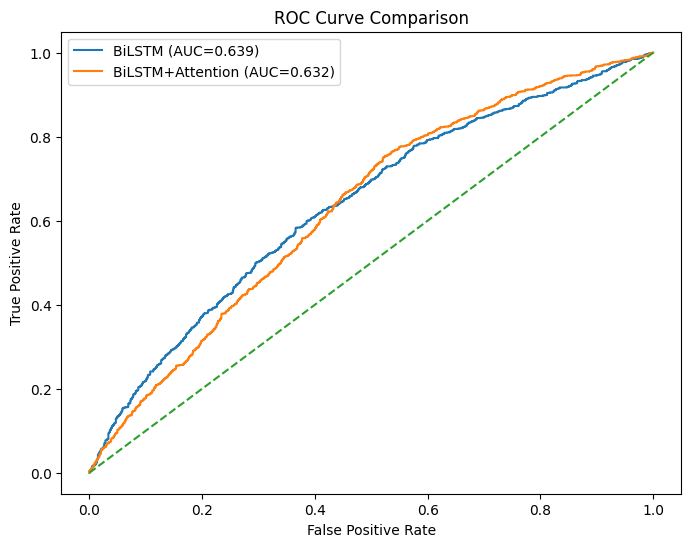

In [ ]:
b_fpr, b_tpr, _ = roc_curve(y_true, b_probs)
a_fpr, a_tpr, _ = roc_curve(y_true, a_probs)

plt.figure(figsize=(8,6))
plt.plot(b_fpr, b_tpr, label=f"BiLSTM (AUC={b_auc:.3f})")
plt.plot(a_fpr, a_tpr, label=f"BiLSTM+Attention (AUC={a_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

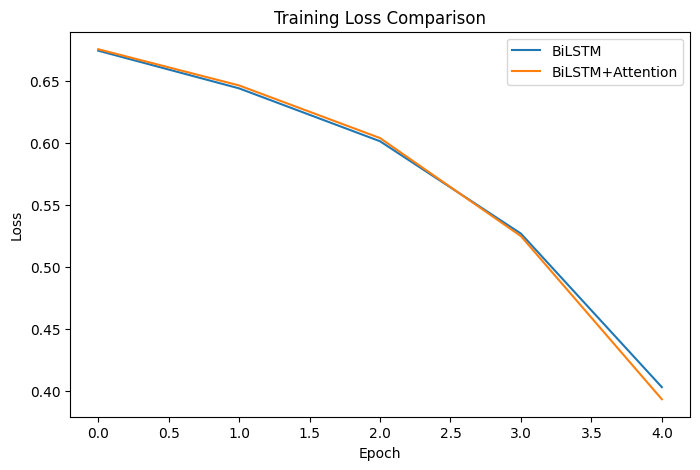

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(bilstm_loss, label="BiLSTM")
plt.plot(attn_loss, label="BiLSTM+Attention")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
def visualize_attention(model, text, vocab, max_len=30):
    model.eval()

    tokens = word_tokenize(text.lower())[:max_len]
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]
    tensor = torch.tensor(ids).unsqueeze(0).to(device)

    with torch.no_grad():
        _, attn = model(tensor)

    scores = attn[0].mean(dim=0).cpu().numpy()[:len(tokens)]

    plt.figure(figsize=(12,2))
    sns.heatmap([scores], annot=[tokens], fmt="", cmap="Reds", cbar=True)
    plt.title("Attention Heatmap")
    plt.show()

Sample Text:
 today in america 70 percent of us are earning the same or less than we were 12 years ago and this is the first time that that has happened this side of world war ii


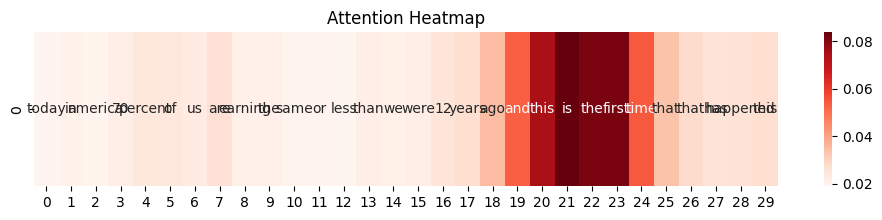

In [ ]:
sample_text = test_df["text"].iloc[10]
print("Sample Text:\n", sample_text)

visualize_attention(attn_model, sample_text, vocab)